<a href="https://colab.research.google.com/github/mlsosave/genai/blob/main/Lab2_BBDD_Vectoriales_LETRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 3: Bases de datos vectoriales

En este ejercicio, exploraremos cómo aprovechar modelos de embedding para transformar datos textuales en representaciones vectoriales, almacenarlas en una base de datos vectorial y realizar búsquedas semánticas.
Antes de comenzar el laboratorio, estaremos usando GPU para el computo de los embeddings locales, por lo tanto, deben de ir a la seccion inferior de COLAB y cambiar el runtime a una GPU T4:
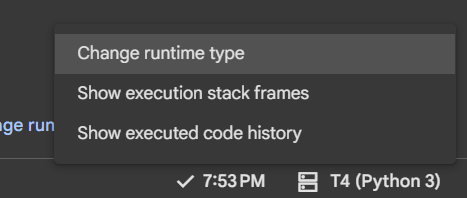

A lo largo de este laboratorio, realizarás las siguientes tareas:

1.  **Extracción de información de un archivo CSV**: Cargarás datos desde un archivo CSV.
2.  **Creación de embeddings**: Emplearás un modelo de embedding pre-entrenado para convertir la información en vectores (embeddings).
3.  **Almacenamiento en una BBDD vectorial**: Almacenarás los embeddings generados en un índice.
4.  **Búsquedas semánticas**: Realizarás búsquedas semánticas en el índice para encontrar información relevante.

# Pinecone

## Extracción de información de un archivo CSV

Carga el archivo home_depot_data.csv (https://www.kaggle.com/datasets/thedevastator/the-home-depot-products-dataset) en un DataFrame de pandas.

In [5]:
import pandas as pd

df = pd.read_csv('home_depot_data.csv')
display(df.head())

,index,url,title,images,description,product_id,sku,gtin13,brand,price,currency,availability,uniq_id,scraped_at
0,0,https://www.homedepot.com/p/Carhartt-Men-s-3X-Large-Carbon-Heather-Cotton-Polyester-Rain-Defender-Paxton-Heavyweight-Hooded-Zip-Front-Sweatshirt-100614-026/310090686,Men's 3X Large Carbon Heather Cotton/Polyester Rain Defender Paxton Heavyweight Hooded Zip-Front Sweatshirt,https://images.thdstatic.com/productImages/a7cd0597-7d1d-4305-a4ec-b50abad8b146/svn/carhartt-hoodies-sweatshirts-100614-026-64_100.jpg~https://images.thdstatic.com/productImages/46653d55-acac-43fc-827d-2633053fe247/svn/carhartt-hoodies-sweatshirts-100614-026-1f_100.jpg,"This heavyweight, water-repellent hooded sweatshirt has a zip front for fast layering. ORIGINAL FIT. 13 oz., 75% cotton/25% polyester blend with Rain Defender durable water repellent. Attached, jersey-lined three-piece hood with drawcord closure. Antique-finish brass front zipper. Two front hand-warmer pockets have a hidden security pocket inside. Stretchable, spandex-reinforced rib-knit cuffs and waistband. Locker loop facilitates hanging.",310090686,1.004455e+09,8.868595e+11,Carhartt,64.99,USD,InStock,ba6b9373-a145-5203-a7fe-5d9ede759dbb,2021-12-14 00:55:53.060268
1,1,https://www.homedepot.com/p/Turmode-30-ft-RP-TNC-Female-to-RP-TNC-Male-Adapter-Cable-WL6068/206724580,Turmode 30 ft. RP TNC Female to RP TNC Male Adapter Cable,https://images.thdstatic.com/productImages/87a93598-8b3d-461e-bced-d6877bd461b6/svn/telephone-cords-wl6068-64_100.jpg,"If you need more length between your existing wireless device and Hi-Gain Antenna, this is the product for you. It's compatible with most Wi-Fi Antennas, so it is easy for you to extend your wireless network. Just replace your existing cable that runs between your wireless device and Antenna and you're ready to use your network with extended range.",206724580,1.001661e+09,6.697163e+11,Unbranded,71.61,USD,InStock,70b7dd77-6474-5085-9afa-cda486a7237d,2021-12-14 00:55:53.070474
2,2,https://www.homedepot.com/p/Carolina-Pet-Company-Large-Tapestry-Bolster-Bed-011260/310347105,Large Tapestry Bolster Bed,https://images.thdstatic.com/productImages/e6b758e6-8597-4fbd-92d7-525b178ea44e/svn/carolina-pet-company-dog-beds-pillows-011260-64_100.jpg~https://images.thdstatic.com/productImages/ac7d2697-df88-4e13-ba2b-ab8ee7e41322/svn/carolina-pet-company-dog-beds-pillows-011260-c3_100.jpg~https://images.thdstatic.com/productImages/a227063b-3952-4e1b-9d0a-0140575790e7/svn/carolina-pet-company-dog-beds-pillows-011260-4f_100.jpg~https://images.thdstatic.com/productImages/c2954a2b-c338-428c-b9cf-27bfe9646994/svn/carolina-pet-company-dog-beds-pillows-011260-1f_100.jpg~https://images.thdstatic.com/productImages/95e8fc41-998e-40f8-965b-8a0255a59ff0/svn/carolina-pet-company-dog-beds-pillows-011260-44_100.jpg~https://images.thdstatic.com/productImages/fe928ad7-32d2-43e5-8b97-d5a2c92b9ac2/svn/carolina-pet-company-dog-beds-pillows-011260-fa_100.jpg,"Polyester cover resembling rich Italian tapestries wraps your pet in comfort and style. 100% recycled polyester high loft MemoryFiber fill keeps pets elevated off cold floors for relief on tired joints and pressure points. A great fit for pets up to 100 lbs. Zippered removable cover is machine washable in cold water only. To dry, use a delicate cycle or gentle setting with very low heat.",310347105,1.005202e+09,8.300001e+11,Carolina Pet Company,166.83,USD,InStock,8f573cae-947d-5262-8e51-b9381e8babeb,2021-12-14 00:55:53.677894
3,3,https://www.homedepot.com/p/16-Gauge-Sinks-Vessel-Sink-in-White-with-Faucet-16GS-22478/312338711,16-Gauge-Sinks Vessel Sink in White with Faucet,https://images.thdstatic.com/productImages/a6eea537-2ed9-4097-9777-f01c5a264341/svn/white-enamel-glaze-vessel-sinks-16gs-22478-64_100.jpg~https://images.thdstatic.com/productImages/4a8f8f41-e016-448a-9057-fbfad5715c40/svn/white-enamel-glaze-vessel-sinks-16gs-22478-1d_100.jpg~https://images.thdstatic.com/productImages/964900ed-b528-41ca-b4bd-dd5151583cc0/sv

## Prepara los datos para la generación de embeddings

Selecciona las columnas de texto relevantes del DataFrame que serán utilizadas para generar los embeddings. En caso necesario, combina varias columnas (por ejemplo, nombre del producto y descripción) en un solo campo de texto.


In [6]:
#
# CÓDIGO
#

# Crear texto consolidado para embeddings
df["text_for_embedding"] = (
    "Title: " + df["title"].fillna('') + ". " +
    "Brand: " + df["brand"].fillna('') + ". " +
    "Description: " + df["description"].fillna('')
)

# Ver resultado
display(df[["text_for_embedding"]].head())

,text_for_embedding
0,"Title: Men's 3X Large Carbon Heather Cotton/Polyester Rain Defender Paxton Heavyweight Hooded Zip-Front Sweatshirt. Brand: Carhartt. Description: This heavyweight, water-repellent hooded sweatshirt has a zip front for fast layering. ORIGINAL FIT. 13 oz., 75% cotton/25% polyester blend with Rain Defender durable water repellent. Attached, jersey-lined three-piece hood with drawcord closure. Antique-finish brass front zipper. Two front hand-warmer pockets have a hidden security pocket inside. Stretchable, spandex-reinforced rib-knit cuffs and waistband. Locker loop facilitates hanging."
1,"Title: Turmode 30 ft. RP TNC Female to RP TNC Male Adapter Cable. Brand: Unbranded. Description: If you need more length between your existing wireless device and Hi-Gain Antenna, this is the product for you. It's compatible with most Wi-Fi Antennas, so it is easy for you to extend your wireless network. Just replace your existing cable that runs between your wireless device and Antenna and you're ready to use your network with extended range."
2,"Title: Large Tapestry Bolster Bed. Brand: Carolina Pet Company. Description: Polyester cover resembling rich Italian tapestries wraps your pet in comfort and style. 100% recycled polyester high loft MemoryFiber fill keeps pets elevated off cold floors for relief on tired joints and pressure points. A great fit for pets up to 100 lbs. Zippered removable cover is machine washable in cold water only. To dry, use a delicate cycle or gentle setting with very low heat."
3,Title: 16-Gauge-Sinks Vessel Sink in White with Faucet. Brand: Unbranded. Description: It features a rectangle shape. This vessel set is designed to be installed as a undermount vessel set. It is constructed with ceramic. This vessel set comes with an enamel glaze finish in White color. It is designed for a deck mount faucet.
4,Title: Men's Crazy Horse 9'' Logger Boot - Steel Toe - Black Size 10.5(W). Brand: Adtec. Description: This 9 in. black full grain leather logger boot is Tough. With plain soft toe and rubber outsole it provides dependable traction with a comfortable fit. It is made with Goodyear Welt Construction so it is sturdy and secure.


## Cargado de modelo de embedding

Cargar el modelo de embeddings all-MiniLM-L6-v2 utilizando la librería sentence-transformers.

In [7]:
#
# CÓDIGO
#

try:
    from sentence_transformers import SentenceTransformer
    print("sentence-transformers ya está instalada")

except ImportError:
    print("Instalando sentence-transformers...")
    !pip install sentence-transformers

    from sentence_transformers import SentenceTransformer

# Cargar modelo de embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
texto = "Heavyweight water-resistant hoodie"

embedding = model.encode(texto)

print(type(embedding))
print(len(embedding))

sentence-transformers ya está instalada


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

<class 'numpy.ndarray'>
384


Definir una función que, dado un texto, retorne su vector de embeddings en forma de lista.

In [8]:
#
# CÓDIGO
#

# Función para generar embeddings
def get_embedding(text):
    embedding = model.encode(text)
    return embedding.tolist()

texto = "Water-resistant hoodie for outdoor work"

vector = get_embedding(texto)

print(type(vector))
print(len(vector))
print(vector[:5])  # primeros valores

<class 'list'>
384
[-0.10486903786659241, 0.15258213877677917, 0.011117440648376942, 0.06310620158910751, 0.12549202144145966]


## Creación del índice en Pinecone

En esta sección deberás establecer una conexión a tu cuenta de Pinecone utilizando tu API KEY. Para esto tendrás que crearte una cuenta en Pinecone (https://www.pinecone.io/).

Inicializar Pinecone utilizando la clave de API guardada en userdata.

In [9]:
#
# CÓDIGO
#

try:
    from pinecone import Pinecone
    print("pinecone ya está instalada")

except ImportError:
    print("Instalando pinecone...")
    !pip install pinecone

    from pinecone import Pinecone

from google.colab import userdata

# Obtener API Key
PINECONE_API_KEY = userdata.get('PINECONE_API_KEY')

# Inicializar cliente
pc = Pinecone(api_key=PINECONE_API_KEY)

print("Pinecone inicializado correctamente")

Instalando pinecone...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 15.7 MB/s eta 0:00:00
Pinecone inicializado correctamente


Crear un índice en Pinecone con la dimensión correspondiente al modelo y con la métrica cosine.

In [10]:
#
# CÓDIGO
#
from pinecone import ServerlessSpec

index_name = "home-depot-index"

# Verificar si el índice ya existe
if index_name not in [index.name for index in pc.list_indexes()]:

    pc.create_index(
        name=index_name,
        dimension=384,          # dimensión del modelo all-MiniLM-L6-v2
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

    print(f"Índice '{index_name}' creado correctamente")

else:
    print(f"El índice '{index_name}' ya existe")

index = pc.Index(index_name)

print("Conexión al índice lista")

El índice 'home-depot-index' ya existe
Conexión al índice lista


## Cargado del índice

Implementa el código necesario para recorrer los datos del DataFrame, generar los embeddings correspondientes y realizar la inserción de la información en el índice creado previamente. Se debe utilizar un esquema de procesamiento por lotes para optimizar la carga.

In [11]:
#
# CÓDIGO
#
# Lo hacmos creando batches de registros, generando los embeddings del lote
# completo y luego haciendo upsert a Pinecone.
# Este enfoque es mucho más eficiente que insertar uno por uno
# tqdm es una librería que muestra una barra de progreso mientras corre un loop.

from tqdm import tqdm

# Tamaño del lote
batch_size = 100

# Recorrer DataFrame por lotes
for i in tqdm(range(0, len(df), batch_size)):

    # Seleccionar lote
    batch = df.iloc[i:i + batch_size]

    # Obtener textos
    texts = batch["text_for_embedding"].tolist()

    # Generar embeddings del lote
    embeddings = model.encode(texts).tolist()

    # Preparar vectores para Pinecone
    vectors = []

    for j, (_, row) in enumerate(batch.iterrows()):

        vector = {
            "id": str(row["uniq_id"]),
            "values": embeddings[j],
            "metadata": {
                "title": row["title"],
                "brand": row["brand"],
                "description": row["description"],
                "price": float(row["price"]) if pd.notnull(row["price"]) else None,
                "url": row["url"]
            }
        }

        vectors.append(vector)

    # Insertar lote en Pinecone - upsert = update if exist or insert if not)
    index.upsert(vectors=vectors)

print("Carga de embeddings completada")

100%|██████████| 26/26 [03:59<00:00,  9.20s/it]

Carga de embeddings completada


## Verificación de datos en el índice

Verifica las estadísticas del índice para asegurarte de que los datos se hayan cargado correctamente.

In [12]:
#
# CÓDIGO
#
# Ver estadísticas del índice
stats = index.describe_index_stats()

print(stats)

DescribeIndexStatsResponse(dimension=384, total_vector_count=2551, metric='cosine', namespaces=1)


## Búsqueda semántica

Realiza consultas al índice utilizando consultas del estilo "best tool for repairing walls" y muestra los resultados obtenidos.

In [13]:
#
# CÓDIGO


# Consulta de ejemplo
query = "best tool for repairing walls"

# Generar embedding de la consulta
query_embedding = model.encode(query).tolist()

# Buscar en Pinecone
results = index.query(
    vector=query_embedding,
    top_k=5,
    include_metadata=True
)

# Mostrar resultados
for match in results["matches"]:

    print(f"Score: {match['score']:.4f}")
    print(f"Title: {match['metadata'].get('title')}")
    print(f"Brand: {match['metadata'].get('brand')}")
    print(f"Price: {match['metadata'].get('price')}")
    print(f"URL: {match['metadata'].get('url')}")
    print("-" * 60)



Score: 0.4360
Title: 4 in. Eclipse Wall Repair Patch (2-Pack)
Brand: DAP
Price: 23.96
URL: https://www.homedepot.com/p/DAP-4-in-Eclipse-Wall-Repair-Patch-2-Pack-7079809164/317967195
------------------------------------------------------------
Score: 0.4244
Title: Wallpaper Scoring Tool (6-Pack)
Brand: Zinsser
Price: 43.56
URL: https://www.homedepot.com/p/Zinsser-Wallpaper-Scoring-Tool-6-Pack-338845/305793766
------------------------------------------------------------
Score: 0.3360
Title: 11 in. x 14 in. "Bless The Food Kitchen Dining Room Textured Word" by Stephanie Workman Marrott Framed Wall Art
Brand: Stupell Industries
Price: 28.16
URL: https://www.homedepot.com/p/Stupell-Industries-11-in-x-14-in-Bless-The-Food-Kitchen-Dining-Room-Textured-Word-by-Stephanie-Workman-Marrott-Framed-Wall-Art-kwp-2087-fr-11x14/311267100
------------------------------------------------------------
Score: 0.3346
Title: Driftwood Grain Paper Strippable Wallpaper (Covers 56.9 sq. ft.)
Brand: York Wallcove

# FAISS
Realiza una práctica de búsqueda semántica utilizando FAISS y un dataset del sitio web https://www.kaggle.com/datasets.

## Cargar el nuevo dataset

Carga el archivo en un DataFrame de pandas.


In [28]:
#
# CÓDIGO
#

# Podés hacer la búsqueda semántica en FAISS exactamente igual que en Pinecone:
# primero convertís la consulta en embedding y después buscás los vectores
# más similares.

# Instalar solo si hace falta
try:
    import faiss
except ImportError:
    !pip install faiss-cpu
    import faiss

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    !pip install sentence-transformers
    from sentence_transformers import SentenceTransformer

import pandas as pd

# Cargar dataset
df = pd.read_csv("movies.csv")

# Crear texto consolidado
df["text"] = (
    df["title"].fillna('') + ". " +
    df["overview"].fillna('')
)

# Eliminar textos vacíos reales
df = df[df["text"].str.strip() != ""]

# Ver resultados
display(df[["text"]].head())


,text
0,"Avatar. In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization."
1,"Pirates of the Caribbean: At World's End. Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems."
2,"Spectre. A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE."
3,"The Dark Knight Rises. Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy."
4,"John Carter. John Carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of Barsoom (Mars) and reluctantly becomes embroiled in an epic conflict. It's a world on the brink of collapse, and Carter rediscovers his humanity when he realizes the survival of Barsoom and its people rests in his hands."


## Preparar los datos para la generación de embeddings

Selecciona las columnas de texto relevantes del nuevo DataFrame que serán utilizadas para generar los embeddings. Combina las columnas necesarias en un solo campo de texto.


In [29]:
#
# CÓDIGO
#

# Crear columna de texto consolidada
df["text_for_embedding"] = (
    "Title: " + df["title"].fillna('') + ". " +
    "Genres: " + df["genres"].fillna('') + ". " +
    "Overview: " + df["overview"].fillna('')
)
print (df.head())
df = df[df["text_for_embedding"].str.strip() != ""]
pd.set_option('display.max_colwidth', None)

display(df[["text_for_embedding"]].head())

   index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   
2      2  245000000                    Action Adventure Crime   
3      3  250000000               Action Crime Drama Thriller   
4      4  260000000          Action Adventure Science Fiction   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                                                       keywords  \
0                           culture clash future space war space colony society   
1  ocean drug abuse exotic island east india trading company love of one's life   
2    

,text_for_embedding
0,"Title: Avatar. Genres: Action Adventure Fantasy Science Fiction. Overview: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization."
1,"Title: Pirates of the Caribbean: At World's End. Genres: Adventure Fantasy Action. Overview: Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems."
2,"Title: Spectre. Genres: Action Adventure Crime. Overview: A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE."
3,"Title: The Dark Knight Rises. Genres: Action Crime Drama Thriller. Overview: Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy."
4,"Title: John Carter. Genres: Action Adventure Science Fiction. Overview: John Carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of Barsoom (Mars) and reluctantly becomes embroiled in an epic conflict. It's a world on the brink of collapse, and Carter rediscovers his humanity when he realizes the survival of Barsoom and its people rests in his hands."


## Generar embeddings

Aplica la función para generar los embeddings para el texto preparado en el paso anterior.


In [30]:
#
# CÓDIGO
#
# Generar embeddings para todos los textos
embeddings = model.encode(
    df["text_for_embedding"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

## Crear un índice FAISS

Inicializa un índice FAISS con la dimensión correcta para los embeddings generados.

In [31]:
!pip install faiss-cpu

In [32]:
#
# CÓDIGO
#

import faiss
import numpy as np

# Generar embeddings
embeddings = model.encode(
    df["text"].tolist(),
    show_progress_bar=True
)

# Convertir a numpy float32
embeddings = np.array(embeddings).astype("float32")

# Obtener dimensión, con el modelo all-MiniLM-L6-v2 la dimension es 384
dimension = embeddings.shape[1]

print("Dimensión embeddings:", dimension)

# Crear índice FAISS
index = faiss.IndexFlatL2(dimension)

# Agregar embeddings al índice
index.add(embeddings)

print("Cantidad de vectores indexados:", index.ntotal)

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

Dimensión embeddings: 384
Cantidad de vectores indexados: 4803


## Agregar embeddings al índice FAISS

Agrega los embeddings generados al índice FAISS.

In [34]:
#
# CÓDIGO
#
# Agregar embeddings al índice. Index.add carga todos los vectores en memoria
# para que FAISS pueda: compararlos, calcular similitudes,
# buscar vecinos cercanos rápidamente.

# index.add(embeddings) # This line was causing duplicate entries in the FAISS index.

print("Cantidad total de vectores:", index.ntotal)

Cantidad total de vectores: 4803


## Realizar búsquedas semánticas en FAISS

Realiza consultas al índice FAISS utilizando consultas de texto y muestra los resultados obtenidos.

In [35]:
#
# CÓDIGO
#

# Consulta semántica
query = "space adventure movie"

# Generar embedding de la consulta
query_embedding = model.encode([query]).astype("float32")

# Buscar los 5 resultados más similares
k = 5

distances, indices = index.search(query_embedding, k)

# Mostrar resultados
for i, idx in enumerate(indices[0]):

    print(f"\nResultado #{i+1}")

    print("Título:")
    print(df.iloc[idx]["title"])

    print("\nDescripción:")
    print(df.iloc[idx]["overview"])

    print("\nDistancia:")
    print(distances[0][i])

    print("-" * 60)

# Probar varias consultas

queries = [
    "romantic comedy",
    "space exploration adventure",
    "crime thriller detective",
    "superhero action movie",
    "animated film for kids"
]

for query in queries:

    print(f"\n{'='*80}")
    print("CONSULTA:", query)

    # Embedding consulta
    query_embedding = model.encode([query]).astype("float32")

    # Buscar
    distances, indices = index.search(query_embedding, 3)

    # Mostrar top resultados
    for i, idx in enumerate(indices[0]):

        print(f"\nResultado #{i+1}")
        print("Título:", df.iloc[idx]["title"])
        print("Distancia:", distances[0][i])


Resultado #1
Título:
Wing Commander

Descripción:
The Hollywood version of the popular video game series "Wing Commander". Unlike other video games to feature film transitions, series creator Chris Roberts was heavily involved in the film's creation. This is the story of Christopher Blair and Todd "Maniac" Marshall as they arrive at the Tiger Claw and are soon forced to stop a Kilrathi fleet heading towards Earth.

Distancia:
1.0090432
------------------------------------------------------------

Resultado #2
Título:
Gravity

Descripción:
Dr. Ryan Stone, a brilliant medical engineer on her first Shuttle mission, with veteran astronaut Matt Kowalsky in command of his last flight before retiring. But on a seemingly routine spacewalk, disaster strikes. The Shuttle is destroyed, leaving Stone and Kowalsky completely alone-tethered to nothing but each other and spiraling out into the blackness of space. The deafening silence tells them they have lost any link to Earth and any chance for re